In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Reshape
from tensorflow.keras.models import Model
from tensorflow.keras import Input
import random



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

def build_discriminator(input_shape):
    model = Sequential()
    model.add(Dense(128, input_shape=input_shape))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(64))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(32))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))  # Saída binária

    # Compilação com parâmetros padrão de GANs
    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
        metrics=['accuracy']
    )
    return model

In [ ]:
def build_generator(latent_dim):
    model = Sequential()
    '''model.add(Dense(64, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(32))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(33, activation='linear'))  # Saída: TAG gerada (shape 11,)'''
    # Camada reduzida
    model.add(Dense(32, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))

    # Segunda camada também reduzida
    model.add(Dense(16))
    model.add(LeakyReLU(alpha=0.2))

    # Saída compatível com o tamanho da TAG (33)
    model.add(Dense(33, activation='linear'))

    return model

In [ ]:
def build_gan(generator, discriminator):
    discriminator.trainable = False
    gan_input = Input(shape=(latent_dim,)) #ruido inicial usado pelo gerador. gan_input é um tensor com dimensao latent_dim
    generated_tag = generator(gan_input)
    gan_output = discriminator(generated_tag) #a saida o gerador passa pelo discriminador pra obter a probabilidade de ser real
    gan_model = Model(gan_input, gan_output)
    gan_model.compile(loss='binary_crossentropy', optimizer=Adam(0.0002))
    return gan_model

In [ ]:
import os

def save_models(generator, discriminator, epoch, g_loss, d_loss, folder="saved_models"):
    os.makedirs(folder, exist_ok=True)
    generator.save(os.path.join(folder, f"generator_epoch{epoch:03d}_gloss{g_loss:.4f}.h5"))
    discriminator.save(os.path.join(folder, f"discriminator_epoch{epoch:03d}_dloss{d_loss:.4f}.h5"))
    print(f"✔️ Modelos salvos na época {epoch}")


In [ ]:
def train_gan(generator, discriminator, gan, X_train, epochs, batch_size, latent_dim):
    half_batch = batch_size // 2
    previous_d_acc = 0.0  # Armazena a acurácia anterior do discriminador
    for epoch in range(epochs):
        # === Treinamento do Discriminador ===
        for _ in range(4):  # Dois passos de treino do discriminador
          # Seleciona uma amostra aleatória real
          idx = np.random.randint(0, X_train.shape[0], half_batch)
          real_tags = X_train[idx]

          # Adiciona leve ruído para robustez
          real_tags += np.random.normal(0, 0.06, real_tags.shape)

          # Gera TAGs falsas
          noise = np.random.normal(0, 1, (half_batch, latent_dim)) #o ruido tem dimensao de metade do batch e latent_dim
          fake_tags = generator.predict(noise)
          fake_tags += np.random.normal(0, 0.06, fake_tags.shape)

          # Rótulos
          real_y = np.ones((half_batch, 1))
          fake_y = np.zeros((half_batch, 1))

          # Torna o discriminador treinável
          discriminator.trainable = True
          d_loss_real = discriminator.train_on_batch(real_tags, real_y)
          d_loss_fake = discriminator.train_on_batch(fake_tags, fake_y)

        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake) # perda média entre real e falso
        # Verifica se a acurácia caiu
        current_d_acc = d_loss[1]
        if current_d_acc < previous_d_acc - 0.02:
            print(f"Parando o treino: acurácia do discriminador caiu ({previous_d_acc*100:.2f}% → {current_d_acc*100:.2f}%) na época {epoch+1}")
            break
        previous_d_acc = current_d_acc  # atualiza a acurácia anterior

        # === Treinamento da GAN (gerador) ===
        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        valid_y = np.ones((batch_size, 1))   # O gerador quer "enganar" o discriminador, entao ele vai dizer que o ruido é 1.

        # Congela o discriminador durante o treinamento do gerador
        discriminator.trainable = False
        g_loss = gan.train_on_batch(noise, valid_y) #treinando o gerador compilado/embutido na gan

        # === Exibe progresso ===
        if epoch % 50 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1}/{epochs} | D_loss: {d_loss[0]:.4f} | D_acc: {d_loss[1]*100:.2f}% | G_loss: {g_loss:.4f}")
        # === Parada se acurácia do discriminador ≥ 90% ===
        if d_loss[1] >= 0.85: #d_loss é um vetor [loss, accuracy]
            discriminator.save("discriminator_85acc.h5")
            print(f"\n🛑 Parando: acurácia do discriminador atingiu {d_loss[1]*100:.2f}% na época {epoch+1}")
            break


#Geração das TAGs


In [ ]:
def tentmap(x):
    if (x>=-1 and x<0):
        return 2*x + 1
    elif (x>=0 or x<=1):
        return -2*x + 1
    else:
        return 0

def orbit(x, steps):
    xorbit=[x] #ponto inicial S0_(y)
    for i in range(steps):
        x = tentmap(x)
        xorbit.append(x)
    return xorbit
#def cosine_similarity(x, y):
#    return np.dot(x, y) #/ (np.linalg.norm(x) * np.linalg.norm(y))

In [ ]:
K = 32
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
#L = 8 # Replace with the desired value of L (comprimento da TAG, uma fatia da arvore binaria)
#sigma = K - L #valores a serem desconsiderados da orbita

In [ ]:
from sklearn.preprocessing import normalize
x = np.linspace(-1,1,500) # dividindo o intervalo [-1,1] igualmente em 2^3 partes. i = 3
original = np.array([orbit(M, K) for M in x]) # 500 tags com 33 pontos
#original = np.array(original)
print(original[5])



[-0.97995992 -0.95991984 -0.91983968 -0.83967936 -0.67935872 -0.35871743
  0.28256513  0.43486974  0.13026052  0.73947896 -0.47895792  0.04208417
  0.91583166 -0.83166333 -0.66332665 -0.32665331  0.34669339  0.30661323
  0.38677355  0.22645291  0.54709419 -0.09418838  0.81162325 -0.62324649
 -0.24649299  0.50701403 -0.01402806  0.97194389 -0.94388777 -0.88777554
 -0.77555108 -0.55110216 -0.10220432]


In [ ]:
# === Gerando TAGs falsas mais distintas ===
num_false_tags = original.shape[0]
x_false = np.concatenate([
    np.random.uniform(-1.5, -1.0, num_false_tags // 2),
    np.random.uniform(1.0, 1.5, num_false_tags // 2)
])
false_tags = np.array([orbit(x, K) for x in x_false])
#verificar TNR e energia

#false_tags = np.array(false_tags)

In [ ]:
#Tags mais semelhantes:
num_false_tags = original.shape[0]
false_tags = original + np.random.normal(0, 0.2, original.shape)

#Tags Falsas Aleatorias::
#dim = original.shape[1]                        # Dimensão da tag
#falsas = np.random.uniform(low=0, high=1, size=(num_false, dim))

#Adicionando Ruído AWGN

In [ ]:
# Adição de ruído AWGN (normal com média 0 e desvio padrão definido)

sigma_noise = 0.2  # defina o valor do desvio padrão conforme necessário
firstOrbit_noisy = [
    [x + np.random.normal(0, sigma_noise) for x in tag]
    for tag in original]
firstOrbit_noisy = normalize(firstOrbit_noisy, axis=1)
# Adiciona ruído e normaliza
sigma = 0.2
false_tags += np.random.normal(0, sigma, false_tags.shape)
falsas_noisy = normalize(false_tags, axis=1)

In [ ]:
# 4. Concatenar todas as tags (ruidosas): legítimas + falsas
X_all = np.vstack([firstOrbit_noisy, falsas_noisy])  # Total: 2N x D
#X_all = normalize(X_all, norm='l2', axis=1)
y_true = np.array([1]*num_false_tags + [0]*num_false_tags)          # Rótulos reais: 1 = legítima, 0 = falsa


In [ ]:
print(np.linalg.norm(firstOrbit_noisy[0]))  # Deve ser ~1.0
print(np.linalg.norm(falsas_noisy[0]))      # Também ~1.0


1.0
1.0


#Extração da TAG pelo Método classico de similaridade


In [ ]:
X_all[999] == falsas_noisy[499]

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True])

In [ ]:
#firstOrbit_noisy = np.array(firstOrbit_noisy)
from sklearn.metrics.pairwise import cosine_similarity
matriz_corr= cosine_similarity(X_all, original)
#print(matriz_corr)
best_matches = np.argmax(matriz_corr, axis=1) # Para cada entrada, índice da tag mais próxima

best_scores = np.max(matriz_corr, axis=1)         # Similaridade máxima para cada entrada
#print(best_scores)
# 7. Definir limiar: acima disso, classifica como legítima

threshold = 0.7  # Ajustável: ex. 0.8
similarity_preds = (best_scores >= threshold).astype(int)


In [ ]:
latent_dim = 20 #dimensao do ruido com 20 numeros aleatorios
input_shape = (33,)

#TAGs legítimas: y deve ser uma lista ou array de shape (20, 11)
X_train = np.array(firstOrbit_noisy).reshape(-1, 33)

#discriminator = load_model("discriminator_model.h5")
discriminator = build_discriminator(input_shape)
generator = build_generator(latent_dim)
gan = build_gan(generator, discriminator)

# Treinar
train_gan(generator, discriminator, gan, X_train, epochs=200, batch_size=32, latent_dim=latent_dim)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Epoch 1/200 | D_loss: 0.6987 | D_acc: 47.15% | G_loss: 0.6870
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

#Comparando resultados

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve
#escolhendo o melhor threshold para GAN::
gan_scores = discriminator.predict(X_all).flatten()

fpr, tpr, thresholds = roc_curve(y_true, gan_scores)
j_scores = tpr - fpr
j_best_idx = np.argmax(j_scores)
best_threshold = thresholds[j_best_idx]
print(f"Melhor threshold ROC (Youden): {best_threshold:.3f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Melhor threshold ROC (Youden): 0.760


In [ ]:
from sklearn.metrics import accuracy_score
#Melhor threshold pela acuracia:
thresholds = np.linspace(0, 1, 200)
best_acc = 0
best_threshold = 0.5

for t in thresholds:
    preds = (gan_scores >= t).astype(int)
    acc = accuracy_score(y_true, preds)
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print(f"Melhor threshold: {best_threshold:.3f} com acurácia: {best_acc:.4f}")


Melhor threshold: 0.764 com acurácia: 0.7660


In [ ]:
from sklearn.metrics import confusion_matrix
#threshold q minimiza falsos positivos e falsos negativos
best_threshold = 0.5
min_diff = float('inf')

for t in np.linspace(0, 1, 200):
    preds = (gan_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    diff = abs(fp - fn)
    if diff < min_diff:
        min_diff = diff
        best_threshold = t
print(f"Melhor threshold: {best_threshold:.3f}")

Melhor threshold: 0.759


In [ ]:
# 4. Avaliação por GAN (discriminador)

gan_preds = (gan_scores >= best_threshold).astype(int)

# 5. Avaliação dos dois métodos
acc_sim = accuracy_score(y_true, similarity_preds)
conf_sim = confusion_matrix(y_true, similarity_preds)
auc_sim = roc_auc_score(y_true, best_scores)

acc_gan = accuracy_score(y_true, gan_preds)
conf_gan = confusion_matrix(y_true, gan_preds)
auc_gan = roc_auc_score(y_true, gan_scores)

# 6. Impressão dos resultados
print("=== Método Similaridade Cosseno ===")
print(f"Acurácia: {acc_sim:.2f}")
print("Matriz de Confusão:")
print(conf_sim)
print(f"AUC: {auc_sim:.3f}")
# TN FP
# FN TP
print("\n=== Discriminador GAN ===")
print(f"Acurácia: {acc_gan:.2f}")
print("Matriz de Confusão:")
print(conf_gan)
print(f"AUC: {auc_gan:.3f}")

=== Método Similaridade Cosseno ===
Acurácia: 1.00
Matriz de Confusão:
[[500   0]
 [  0 500]]
AUC: 1.000

=== Discriminador GAN ===
Acurácia: 0.77
Matriz de Confusão:
[[500   0]
 [227 273]]
AUC: 0.567


In [ ]:
discriminator.save("discriminator_acc0.7.h5")
generator.save("generator_acc0.7.h5")

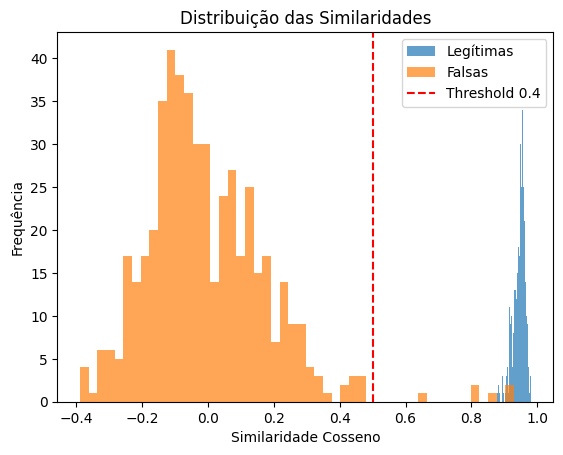

In [ ]:
import matplotlib.pyplot as plt

# Similaridade entre cada tag legítima ruidosa e sua correspondente "melhor"
sims_legit = [
    cosine_similarity(firstOrbit_noisy[i].reshape(1, -1), original[best_matches[i]].reshape(1, -1))[0, 0]
    for i in range(len(original))
]

# Similaridade entre falsas tags e uma legítima aleatória (simulando ataque)
sims_fake = [
    cosine_similarity(tag.reshape(1, -1), original[np.random.randint(0, len(original))].reshape(1, -1))[0, 0]
    for tag in falsas_noisy
]

# Plotagem
plt.hist(sims_legit, bins=50, alpha=0.7, label="Legítimas")
plt.hist(sims_fake, bins=50, alpha=0.7, label="Falsas")
plt.axvline(0.5, color='red', linestyle='--', label='Threshold 0.4')
plt.legend()
plt.title("Distribuição das Similaridades")
plt.xlabel("Similaridade Cosseno")
plt.ylabel("Frequência")
plt.show()


In [ ]:
threshold_sim = np.percentile(sims_fake, 95)  # Apenas 5% das falsas devem ultrapassar
threshold_sim

np.float64(0.287858786232545)

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, best_scores)
best_index = np.argmax(tpr - fpr)
optimal_threshold = thresholds[best_index]
print(f"Limiar ótimo pelo ROC: {optimal_threshold:.3f}")


Limiar ótimo pelo ROC: 1.000


In [ ]:
'''def train_gan(generator, discriminator, gan, X_train, epochs, batch_size, latent_dim):
    batch_count = X_train.shape[0] // batch_size

    for epoch in range(epochs):
        for _ in range(batch_count):

            # === Etapa 1: treinar discriminador ===
            discriminator.trainable = True

            # Amostras falsas
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_tags = generator.predict(noise, verbose=0)

            # Amostras reais
            idx = np.random.randint(0, X_train.shape[0], batch_size)
            real_tags = X_train[idx]

            # === AQUI: adiciona leve ruído extra ===
            real_tags += np.random.normal(0, 0.06, real_tags.shape)
            fake_tags += np.random.normal(0, 0.06, fake_tags.shape)

            # Rótulos para treinamento do discriminador
            real_labels = np.ones((batch_size, 1))*0.9
            fake_labels = np.zeros((batch_size, 1))

            # Treinar discriminador
            d_loss_real = discriminator.train_on_batch(real_tags, real_labels) #treino com tags reais
            d_loss_fake = discriminator.train_on_batch(fake_tags, fake_labels) #treino com tags falsas
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            # === Etapa 2: treinar gerador via GAN ===
            discriminator.trainable = False  # importante!
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            valid_y = np.ones((batch_size, 1))  # Queremos que o gerador engane o discriminador
            g_loss = gan.train_on_batch(noise, valid_y)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch + 1}/{epochs} | D loss: {d_loss[0]:.4f}, acc: {100*d_loss[1]:.2f}% | G loss: {g_loss:.4f}")'''



In [ ]:
'''threshold_sim = 0.9      # threshold do método tradicional
threshold_gan = 0.5      # threshold de decisão do discriminador (sigmoid)

for i in range(len(best_matches)):
    # Verificação de verdade (ground truth)
    true = int(np.allclose(firstOrbit_noisy[i], original[best_matches[i]], atol=0.5))  # Ou com base na associação original
    true_labels.append(true)

    # Método A: Cosine similarity
    sim = cosine_similarity(firstOrbit_noisy[i], original[best_matches[i]])
    similarity_preds.append(1 if sim > threshold_sim else 0)

    # Método B: Discriminador GAN
    d_out = discriminator.predict(np.array([firstOrbit_noisy[i]]))[0][0]
    gan_preds.append(1 if d_out > threshold_gan else 0)'''


'threshold_sim = 0.9      # threshold do método tradicional\nthreshold_gan = 0.5      # threshold de decisão do discriminador (sigmoid)\n\nfor i in range(len(best_matches)):\n    # Verificação de verdade (ground truth)\n    true = int(np.allclose(firstOrbit_noisy[i], original[best_matches[i]], atol=0.5))  # Ou com base na associação original\n    true_labels.append(true)\n\n    # Método A: Cosine similarity\n    sim = cosine_similarity(firstOrbit_noisy[i], original[best_matches[i]])\n    similarity_preds.append(1 if sim > threshold_sim else 0)\n\n    # Método B: Discriminador GAN\n    d_out = discriminator.predict(np.array([firstOrbit_noisy[i]]))[0][0]\n    gan_preds.append(1 if d_out > threshold_gan else 0)'

In [ ]:
'''print("=== Método Similaridade ===")
print("Acurácia:", accuracy_score(true_labels, similarity_preds))
print("Matriz de confusão:\n", confusion_matrix(true_labels, similarity_preds))

# TN FP
# FN TP

print("\n=== Discriminador GAN ===")
print("Acurácia:", accuracy_score(true_labels, gan_preds))
print("Matriz de confusão:\n", confusion_matrix(true_labels, gan_preds))
print("AUC:", roc_auc_score(true_labels, gan_preds)) #quanto mais quadrada melhor (curva)'''


'print("=== Método Similaridade ===")\nprint("Acurácia:", accuracy_score(true_labels, similarity_preds))\nprint("Matriz de confusão:\n", confusion_matrix(true_labels, similarity_preds))\n\n# TN FP\n# FN TP\n\nprint("\n=== Discriminador GAN ===")\nprint("Acurácia:", accuracy_score(true_labels, gan_preds))\nprint("Matriz de confusão:\n", confusion_matrix(true_labels, gan_preds))\nprint("AUC:", roc_auc_score(true_labels, gan_preds)) #quanto mais quadrada melhor (curva)'